# EDA

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import string
import re
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

#pip install pyldavis
import gensim
import pyLDAvis.gensim


[nltk_data] Downloading package punkt to /Users/foongming/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
train_data = pd.read_csv('data/combined_train_preprocessed.csv')
test_data = pd.read_csv('data/combined_test_preprocessed.csv')

# Combine the datasets into one dataframe
# Using concat with ignore_index=True to reset the index
data = pd.concat([train_data, test_data], ignore_index=True)

In [3]:
# Basic info about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2556 entries, 0 to 2555
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         2556 non-null   object
 1   cleaned_text  2537 non-null   object
 2   Bias          2556 non-null   object
dtypes: object(3)
memory usage: 60.0+ KB


In [4]:
# Checking for missing values
missing_values = data.isnull().sum()
print(missing_values)

Title            0
cleaned_text    19
Bias             0
dtype: int64


In [5]:
# Drop rows with any null (NaN) values
data = data.dropna()

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2537 entries, 1 to 2555
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         2537 non-null   object
 1   cleaned_text  2537 non-null   object
 2   Bias          2537 non-null   object
dtypes: object(3)
memory usage: 79.3+ KB


In [6]:
# Drop rows where 'Text' column contains 'Error fetching article'
data = data.rename(columns={'cleaned_text': 'Text'})

data = data[data['Text'] != 'Error fetching article']

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2537 entries, 1 to 2555
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   2537 non-null   object
 1   Text    2537 non-null   object
 2   Bias    2537 non-null   object
dtypes: object(3)
memory usage: 79.3+ KB


In [7]:
def fix_encoding(text):
    # Fix common encoding issues

    text = (text
            .replace('Ã', 'A')
            .replace('Ã“', 'O')
            .replace('Ã§', 'c')
            .replace('Ã¢', 'a')
            .replace('Ã«', 'e')
            .replace('Ã¼', 'u')
            .replace('Ã¯', 'i')
            .replace('â€‘', '-')
            .replace('Ã', 'i')
            .replace('Ãº', 'u')
            .replace('â€‘', ' ')
            .replace('ðŸ¦Ž', ' ')
            .replace('Ã±', 'n')
            .replace('ðŸš¨', '')
            .replace('ðŸ”¥', '')
            .replace('Ã‰', '')
            .replace('â€‚', '')
            .replace('Ã¨', 'e')
            .replace('Ã©', 'e')
            .replace('â„¢', '')
            .replace('Ã¸', 'ø')
            .replace('\xad', '')
            .replace('Ã¡', 'a')
            .replace('Ã³','o')
            .replace('Ã¶', 'o')
            .replace('â€˜', "'")
            .replace('â€“', '-')
            .replace('â€”', '-')
            .replace('â€™', "'")
            .replace('â€œ', '"')
            .replace('â€', '"')
            .replace('â€™','"'))
    return text

## fix encoding issues
for col in ['Title', 'Text', 'Bias']:
    data[col] = data[col].apply(lambda x: fix_encoding(x))

## create helper columns
whitelist_pattern = r"[a-zA-Z\s0-9.$(),\'\":\-\?\[\]\!\%\&;\@\/\*\+\#ø£\=\_]"
t = data['Text'].apply(lambda x: re.sub(whitelist_pattern, '', x))
data['special_symbol_length'] = t.str.len()
data['special_symbol_proportion'] = data['special_symbol_length'] / data['Text'].str.len()
proportion = 0.0014

## filter out high proportions of special symbols - these are non english articles, they are all coming from Apnews source
data = data[~((data['special_symbol_proportion'] > proportion))]

## clean up text of special symbols
special_char_pattern = rf"[^{whitelist_pattern}]"
data['cleaned_text'] = data['Text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

def cols_to_string(data: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    for col in cols:
        data[col] = data[col].astype(str)
    return data

# Convert the data to strings 
data = cols_to_string(data, ['Title', 'Text', 'Bias'])

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2537 entries, 1 to 2555
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Title                      2537 non-null   object 
 1   Text                       2537 non-null   object 
 2   Bias                       2537 non-null   object 
 3   special_symbol_length      2537 non-null   int64  
 4   special_symbol_proportion  2537 non-null   float64
 5   cleaned_text               2537 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 138.7+ KB


In [8]:
# Show the first few rows of the dataset
data.head()

,Title,Text,Bias,special_symbol_length,special_symbol_proportion,cleaned_text
1,Hamas Frees 4 Israeli Soldiers As Part Of Gaza...,tel aviv israel ap four femal isra soldier hel...,left,0,0.0,tel aviv israel ap four femal isra soldier hel...
2,These Progressives Will Guide Us Through the D...,without doubt go toughbut visionari give us ho...,left,0,0.0,without doubt go toughbut visionari give us ho...
3,'It's a free country' - but some White House s...,white hous staffer offic legisl affair presid ...,left,0,0.0,white hous staffer offic legisl affair presid ...
4,VIDEO: 'Crazy' Winter Storm Forces Georgia Dri...,winter storm hit atlanta georgia area tuesday ...,right,0,0.0,winter storm hit atlanta georgia area tuesday ...
5,Rename Mount McKinley? Sarah Palin and Other R...,year ago wife spent night denali overlook inn ...,lean right,0,0.0,year ago wife spent night denali overlook inn ...


In [11]:
# noticed that not all rows are unique, so we will drop duplicates
data = data.drop_duplicates(subset='Title', keep='first')
data = data.drop_duplicates(subset='Text', keep='first')
#data = data.drop_duplicates(subset='Link', keep='first')

## Distribution of Bias over dataset

In [18]:
# Checking the distribution of the 'Bias' column
bias_counts = data['Bias'].value_counts()
bias_percentages = data['Bias'].value_counts(normalize=True) * 100

# Display counts and percentages
print("Count of bias labels:")
print(bias_counts)
print("\nPercentage of bias labels:")
print(bias_percentages.round(2).astype(str) + '%')

Count of bias labels:
Bias
left          1108
right          438
lean left      402
center         356
lean right     232
Name: count, dtype: int64

Percentage of bias labels:
Bias
left          43.69%
right         17.27%
lean left     15.85%
center        14.04%
lean right     9.15%
Name: proportion, dtype: object


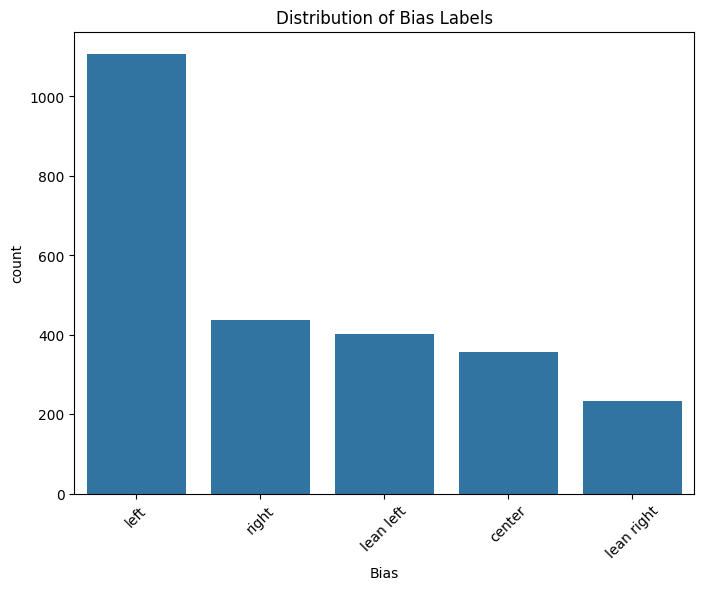

In [14]:
# Visualizing the distribution of Bias labels
plt.figure(figsize=(8,6))
sns.countplot(data=data, x='Bias', order=data['Bias'].value_counts().index)
plt.title('Distribution of Bias Labels')
plt.xticks(rotation=45)
plt.show()

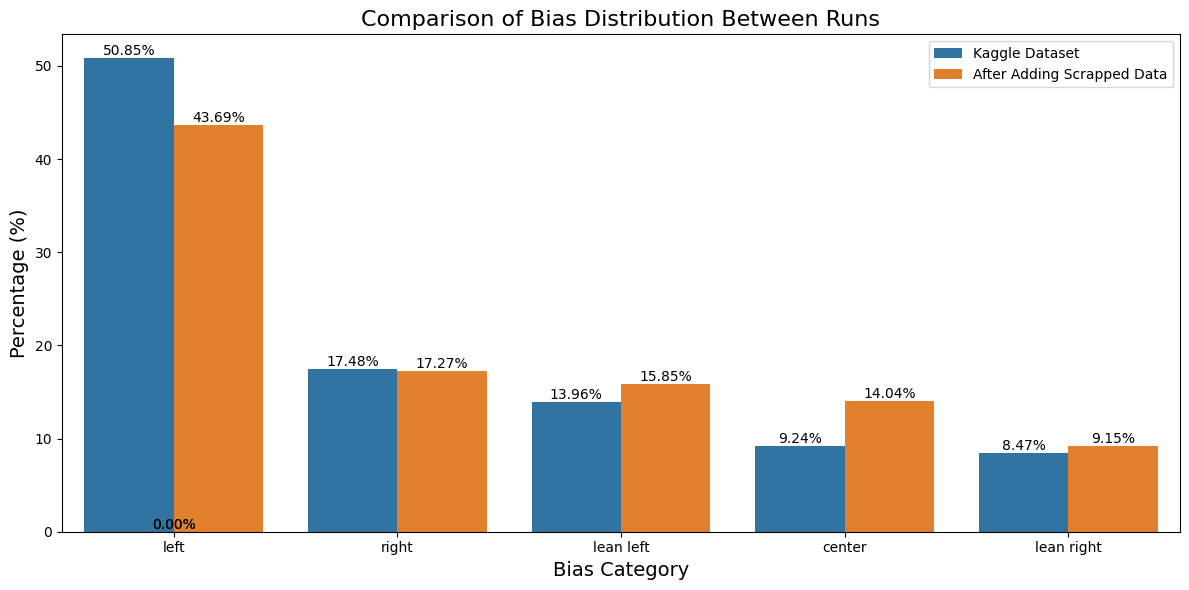

In [21]:
# Your current data
previous_run = {
    'Bias': ['left', 'right', 'lean left', 'center', 'lean right'],
    'Percentage': [50.85, 17.48, 13.96, 9.24, 8.47]
}

# Create DataFrame for the previous run
previous_df = pd.DataFrame(previous_run)

# Assuming you have your current results in the 'bias_percentages' variable
# Convert your current results to a similar format
current_df = pd.DataFrame({
    'Bias': bias_counts.index,
    'Percentage': bias_percentages.values
})

# Combine the data for comparison
previous_df['Source'] = 'Kaggle Dataset'
current_df['Source'] = 'After Adding Scrapped Data'
combined_df = pd.concat([previous_df, current_df])

# Create a grouped bar chart
plt.figure(figsize=(12, 6))
chart = sns.barplot(x='Bias', y='Percentage', hue='Source', data=combined_df)

# Customize the chart
plt.title('Comparison of Bias Distribution Between Runs', fontsize=16)
plt.xlabel('Bias Category', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='')

# Add percentage labels on top of bars
for p in chart.patches:
    chart.annotate(f'{p.get_height():.2f}%', 
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha = 'center', va = 'bottom',
                  fontsize=10)

plt.tight_layout()
plt.show()

With the addition of our scrapped data, the dataset, while still imbalanced, is less imbalanced than before. We expect improvements across all our models after running with the new data. 